Name: Christopher A. Lee\
Date: 04/07/2026\
Prof: Dr. Azarnoosh\
Course: Machine Learning for Data Analysis - ENBC 321

In [1]:
# Libraries
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestCentroid
from sklearn.metrics import silhouette_score

In [2]:
# Import Data
df = pd.read_csv('patients_data.csv')

# Preprocess Data
X1 = df[['Age', 'Blood_Pressure']]
X2 = df[['Age', 'Glucose_Level']]

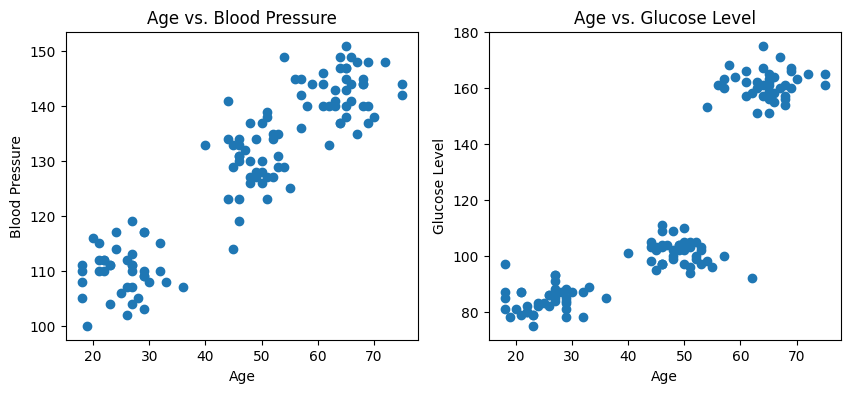

In [3]:
# Data Visualization
fig1, ax1 = plt.subplots(1, 2, figsize=(10,4))

ax1[0].scatter(X1['Age'], X1['Blood_Pressure'])
ax1[0].set_title("Age vs. Blood Pressure")
ax1[0].set_xlabel("Age")
ax1[0].set_ylabel("Blood Pressure")
ax1[1].scatter(X2['Age'], X2['Glucose_Level'])
ax1[1].set_title("Age vs. Glucose Level")
ax1[1].set_xlabel("Age")
ax1[1].set_ylabel("Glucose Level")
plt.show()

In [4]:
# Normalization
X1_scaler, X2_scaler = StandardScaler(), StandardScaler()

X1_scaled, X2_scaled = X1_scaler.fit_transform(X1), X2_scaler.fit_transform(X2)

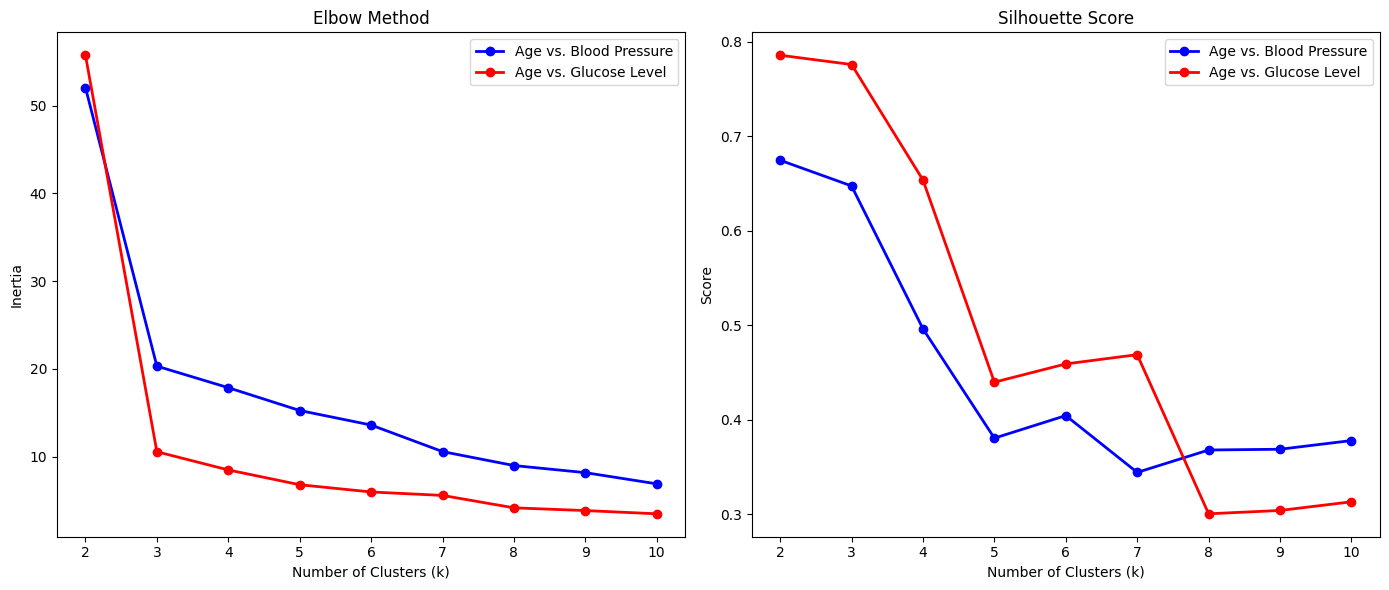

In [5]:
# K-means Clustering
inertia1, sil_scores1 = [], [] 
inertia2, sil_scores2 = [], []
K = range(2, 11)
for k in K:
    kmeans1 = KMeans(n_clusters=k, init='k-means++', random_state=321).fit(X1_scaled)
    inertia1.append(kmeans1.inertia_)
    sil_scores1.append(silhouette_score(X1, kmeans1.labels_))
    
    kmeans2 = KMeans(n_clusters=k, init='k-means++', random_state=321).fit(X2_scaled)
    inertia2.append(kmeans2.inertia_)
    sil_scores2.append(silhouette_score(X2, kmeans2.labels_))

# Elbow Method and Silhouette Analysis Plot
fig2, ax2 = plt.subplots(1, 2, figsize=(14, 6)) 

ax2[0].plot(K, inertia1, 'bo-', linewidth=2, label='Age vs. Blood Pressure')
ax2[0].plot(K, inertia2, 'ro-', linewidth=2, label='Age vs. Glucose Level')
ax2[0].set_title("Elbow Method")
ax2[0].set_xlabel("Number of Clusters (k)")
ax2[0].set_ylabel("Inertia")
ax2[0].legend()

ax2[1].plot(K, sil_scores1, 'bo-', linewidth=2, label='Age vs. Blood Pressure')
ax2[1].plot(K, sil_scores2, 'ro-', linewidth=2, label='Age vs. Glucose Level')
ax2[1].set_title("Silhouette Score")
ax2[1].set_xlabel("Number of Clusters (k)")
ax2[1].set_ylabel("Score")
ax2[1].legend()

plt.tight_layout()
plt.show()


Text(0, 0.5, 'Glucose Level (Scaled)')

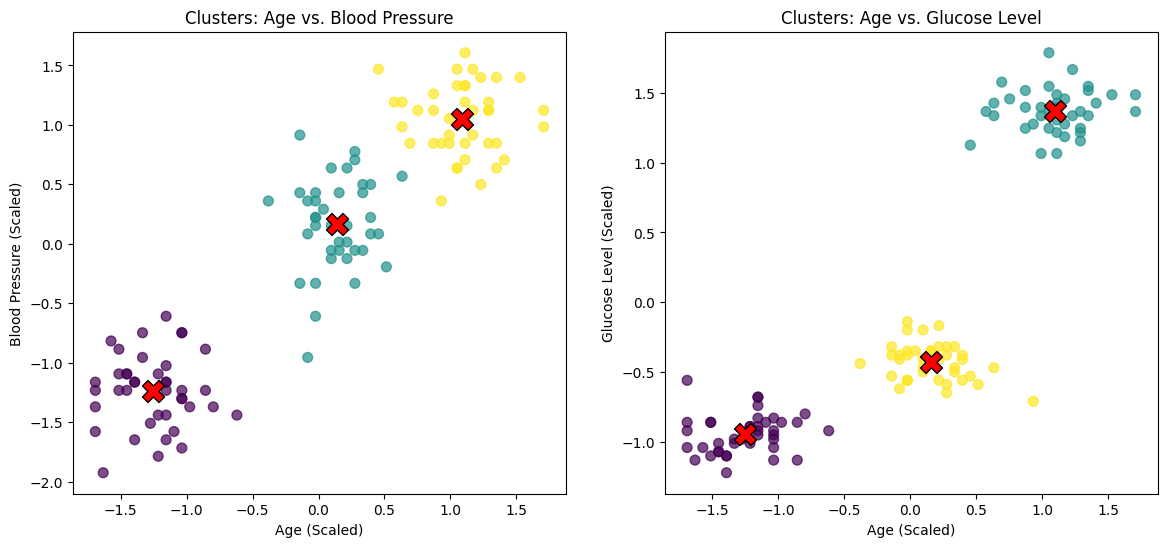

In [6]:
# Optimal k value
# 3 chosen because elbow appears at k=3 for elbow method plot while silhouette score drops around
# k=4 for the silhouette plot reinforcing that the k=3 is a good choice. Specifically, a higher 
# silhouette score is better and the score drops from good to bad when shifting the k to 3 to 4.
k1, k2 = 3, 3

# Kmeans models
model_km1 = KMeans(n_clusters=k1, init='k-means++', random_state=321).fit(X1_scaled)
model_km2 = KMeans(n_clusters=k2, init='k-means++', random_state=321).fit(X2_scaled)

clf1 = NearestCentroid().fit(X1_scaled, model_km1.labels_)
clf2 = NearestCentroid().fit(X2_scaled, model_km2.labels_)

# Clustered 2D plots
fig3, ax3 = plt.subplots(1, 2, figsize=(14, 6)) 
ax3[0].scatter(X1_scaled[:, 0], X1_scaled[:, 1], c=model_km1.labels_, cmap='viridis', s=50, alpha=0.7)
ax3[0].scatter(clf1.centroids_[:, 0], clf1.centroids_[:, 1], c='red', marker='X', s=250, label='Cluster Centers', edgecolors='black')
ax3[0].set_title("Clusters: Age vs. Blood Pressure")
ax3[0].set_xlabel("Age (Scaled)")
ax3[0].set_ylabel("Blood Pressure (Scaled)")

ax3[1].scatter(X2_scaled[:, 0], X2_scaled[:, 1], c=model_km2.labels_, cmap='viridis', s=50, alpha=0.7)
ax3[1].scatter(clf2.centroids_[:, 0], clf2.centroids_[:, 1], c='red', marker='X', s=250, label='Cluster Centers', edgecolors='black')
ax3[1].set_title("Clusters: Age vs. Glucose Level")
ax3[1].set_xlabel("Age (Scaled)")
ax3[1].set_ylabel("Glucose Level (Scaled)")

In [7]:
print("1. Feature scaling is important prior to K-means clustering because different features might \nhave a larger range of values, affecting the Euclidean distance calculated by the kmeans algorithm and \nimpacting final cluster results.")
print("2. Yes, you can obtain different results since random initial centroids will most of the time \nconverge to the local optima rather than the global best solution. To combat this, the k-means++ places \nthe initial centroids to encourage better or more stable convergence.")
print("3. Limitations include the assumption of spherical clusters, which makes the algorithm sensitive \nto outliers. Other algorithms are preferable if the data does not remain in spherical clusters.")

1. Feature scaling is important prior to K-means clustering because different features might 
have a larger range of values, affecting the Euclidean distance calculated by the kmeans algorithm and 
impacting final cluster results.
2. Yes, you can obtain different results since random initial centroids will most of the time 
converge to the local optima rather than the global best solution. To combat this, the k-means++ places 
the initial centroids to encourage better or more stable convergence.
3. Limitations include the assumption of spherical clusters, which makes the algorithm sensitive 
to outliers. Other algorithms are preferable if the data does not remain in spherical clusters.
